In [22]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
df.shape

(101766, 50)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [5]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [6]:
columns_to_drop = [
    'encounter_id',
    'weight',
    'payer_code',

    # Near zero variance
    'examide', 'citoglipton', 'troglitazone', 'acetohexamide',

    # Rare medications
    'nateglinide', 'chlorpropamide', 'tolbutamide',
    'tolazamide', 'miglitol', 'acarbose', 'repaglinide',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone', 'glipizide-metformin',
    'glyburide-metformin'
]

df.drop(columns=columns_to_drop, inplace=True)

In [7]:
df.shape

(101766, 31)

In [8]:
df.columns

Index(['patient_nbr', 'race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'medical_specialty', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses',
       'max_glu_serum', 'A1Cresult', 'metformin', 'glimepiride', 'glipizide',
       'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change',
       'diabetesMed', 'readmitted'],
      dtype='object')

In [9]:
df.isnull().sum()

patient_nbr                     0
race                            0
gender                          0
age                             0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
glimepiride                     0
glipizide                       0
glyburide                       0
pioglitazone                    0
rosiglitazone                   0
insulin                         0
change                          0
diabetesMed   

In [11]:
df.drop(columns=['max_glu_serum', 'A1Cresult', 'medical_specialty'], inplace=True)

In [12]:
df.shape

(101766, 28)

In [13]:
df.isnull().sum()

patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
metformin                   0
glimepiride                 0
glipizide                   0
glyburide                   0
pioglitazone                0
rosiglitazone               0
insulin                     0
change                      0
diabetesMed                 0
readmitted                  0
dtype: int64

In [14]:
df.dtypes

patient_nbr                  int64
race                        object
gender                      object
age                         object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
metformin                   object
glimepiride                 object
glipizide                   object
glyburide                   object
pioglitazone                object
rosiglitazone               object
insulin                     object
change                      object
diabetesMed                 object
readmitted                  object
dtype: object

In [18]:
df.head(10)

,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,metformin,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,insulin,change,diabetesMed,readmitted
0,8222157,Caucasian,Female,[0-10),6,25,1,1,41,0,...,No,No,No,No,No,No,No,No,No,NO
1,55629189,Caucasian,Female,[10-20),1,1,7,3,59,0,...,No,No,No,No,No,No,Up,Ch,Yes,>30
2,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,...,No,No,Steady,No,No,No,No,No,Yes,NO
3,82442376,Caucasian,Male,[30-40),1,1,7,2,44,1,...,No,No,No,No,No,No,Up,Ch,Yes,NO
4,42519267,Caucasian,Male,[40-50),1,1,7,1,51,0,...,No,No,Steady,No,No,No,Steady,Ch,Yes,NO
5,82637451,Caucasian,Male,[50-60),2,1,2,3,31,6,...,No,No,No,No,No,No,Steady,No,Yes,>30
6,84259809,Caucasian,Male,[60-70),3,1,2,4,70,1,...,Steady,Steady,No,No,No,No,Steady,Ch,Yes,NO
7,114882984,Caucasian,Male,[70-80),1,1,7,5,73,0,...,No,No,No,Steady,No,No,No,No,Yes,>30
8,48330783,Caucasian,Female,[80-90),2,1,4,13,68,2,...,No,No,Steady,No,No,No,Steady,Ch,Yes,NO
9,63555939,Caucasian,Female,[90-100),3,3,4,12,33,3,...,No,No,No,No,No,Steady,Steady,Ch,Yes,NO


In [19]:
age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}
df['age_numeric'] = df['age'].map(age_map)

In [20]:
df['age_numeric'].isna().sum()

np.int64(0)

In [21]:
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [56]:
df['readmitted_binary'] = df['readmitted'].apply(
    lambda x: 1 if x == '<30' else 0
)

In [58]:
df['readmitted_binary'].value_counts(normalize=True) * 100

readmitted_binary
0    91.029397
1     8.970603
Name: proportion, dtype: float64

In [23]:
# Replace '?' with NaN across entire dataframe
df.replace('?', np.nan, inplace=True)

In [24]:
# Now check nulls properly
df.isnull().sum()

patient_nbr                    0
race                        2273
gender                         0
age                            0
admission_type_id              0
discharge_disposition_id       0
admission_source_id            0
time_in_hospital               0
num_lab_procedures             0
num_procedures                 0
num_medications                0
number_outpatient              0
number_emergency               0
number_inpatient               0
diag_1                        21
diag_2                       358
diag_3                      1423
number_diagnoses               0
metformin                      0
glimepiride                    0
glipizide                      0
glyburide                      0
pioglitazone                   0
rosiglitazone                  0
insulin                        0
change                         0
diabetesMed                    0
readmitted                     0
age_numeric                    0
dtype: int64

In [26]:
missing = df.isna().sum() / len(df) * 100
missing.sort_values(ascending=False)

race                        2.233555
diag_3                      1.398306
diag_2                      0.351787
diag_1                      0.020636
patient_nbr                 0.000000
discharge_disposition_id    0.000000
admission_source_id         0.000000
time_in_hospital            0.000000
num_lab_procedures          0.000000
num_procedures              0.000000
gender                      0.000000
age                         0.000000
admission_type_id           0.000000
number_emergency            0.000000
number_outpatient           0.000000
num_medications             0.000000
number_inpatient            0.000000
number_diagnoses            0.000000
metformin                   0.000000
glimepiride                 0.000000
glipizide                   0.000000
glyburide                   0.000000
pioglitazone                0.000000
rosiglitazone               0.000000
insulin                     0.000000
change                      0.000000
diabetesMed                 0.000000
r

In [27]:
# race — about 2% missing. Fill with 'Unknown' since race is a demographic category and dropping rows would lose data.
df['race'].fillna('Unknown', inplace=True)

In [28]:
# diag_1, diag_2, diag_3 — very few nulls. Fill with 'Unknown'.
df['diag_1'].fillna('Unknown', inplace=True)
df['diag_2'].fillna('Unknown', inplace=True)
df['diag_3'].fillna('Unknown', inplace=True)

In [29]:
# Check duplicate patient encounters
print(df.duplicated(subset='patient_nbr').sum())

30248


In [30]:
# Keep first occurrence of each patient
df = df.drop_duplicates(subset='patient_nbr', keep='first')

In [32]:
df.shape

(71518, 29)

In [33]:
df['discharge_disposition_id'].value_counts()

discharge_disposition_id
1     44317
3      8784
6      8289
18     2474
2      1539
22     1410
11     1077
5       913
25      778
4       541
7       409
23      260
13      243
14      218
28       90
8        73
15       40
24       25
9         9
17        8
10        6
19        6
27        3
16        3
12        2
20        1
Name: count, dtype: int64

In [34]:
df['discharge_disposition_id'].unique()

array([25,  1,  3,  6,  2,  5, 11,  7, 10, 14,  4, 18,  8, 12, 13, 17, 16,
       22, 23,  9, 15, 20, 28, 24, 19, 27])

In [36]:
# discharge_disposition_id 11=Expired, 13=Hospice, 14=Hospice
df = df[~df['discharge_disposition_id'].isin([11, 13, 14, 19, 20])]

In [50]:
def group_discharge(id_val):
    if id_val in [1, 8]:
        return 'Home'
    elif id_val in [6]:
        return 'Home with Health Support'
    elif id_val in [7]:
        return 'Left Against Medical Advice (AMA)'
    elif id_val in [2, 3, 4, 5, 10, 15, 27]:
        return 'Transferred to Another Facility'
    elif id_val in [22, 23, 24]:
        return 'Transferred to Long Term / Rehab Care'
    elif id_val in [28]:
        return 'Transferred to Psychiatric Care'
    elif id_val in [9, 12, 16, 17]:
        return 'Continued Outpatient / Inpatient Care'
    elif id_val in [18, 25]:
        return 'Not Available / Unknown'
    else:
        return 'Other'

df['discharge_group'] = df['discharge_disposition_id'].apply(group_discharge)

print(df['discharge_group'].value_counts())

discharge_group
Home                                     44390
Transferred to Another Facility          11826
Home with Health Support                  8289
Not Available / Unknown                   3252
Transferred to Long Term / Rehab Care     1695
Left Against Medical Advice (AMA)          409
Transferred to Psychiatric Care             90
Continued Outpatient / Inpatient Care       22
Name: count, dtype: int64


In [37]:
admission_type_map = {
    1: 'Emergency', 2: 'Urgent', 3: 'Elective',
    4: 'Newborn', 5: 'Not Available', 6: 'NULL', 7: 'Trauma',
    8: 'Not Mapped'
}
df['admission_type'] = df['admission_type_id'].map(admission_type_map)

In [39]:
df['admission_source_id'].unique()

array([ 1,  7,  2,  4,  5, 20,  6,  3, 17,  8,  9, 14, 10, 22, 11, 25, 13])

In [44]:
# For analysis, raw categories are too detailed. You should group them into meaningful buckets like:
def group_admission_source(id_val):
    if id_val in [7]:
        return 'Emergency Room'
    elif id_val in [1, 2, 3]:
        return 'Referral'
    elif id_val in [4, 5, 6, 10, 22, 25]:
        return 'Transfer'
    elif id_val in [8]:
        return 'Court / Law Enforcement'
    elif id_val in [11, 13, 14]:
        return 'Birth Related'        # flag to remove later
    elif id_val in [9, 17, 20]:
        return 'Not Available / Unknown'
    else:
        return 'Other'

df['admission_source_group'] = df['admission_source_id'].apply(group_admission_source)


In [46]:
df.head(10)

,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,pioglitazone,rosiglitazone,insulin,change,diabetesMed,readmitted,age_numeric,discharge_category,admission_type,admission_source_group
0,8222157,Caucasian,Female,[0-10),6,25,1,1,41,0,...,No,No,No,No,No,NO,5,Not Mapped,NULL,Referral
1,55629189,Caucasian,Female,[10-20),1,1,7,3,59,0,...,No,No,Up,Ch,Yes,>30,15,Discharged to home,Emergency,Emergency Room
2,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,...,No,No,No,No,Yes,NO,25,Discharged to home,Emergency,Emergency Room
3,82442376,Caucasian,Male,[30-40),1,1,7,2,44,1,...,No,No,Up,Ch,Yes,NO,35,Discharged to home,Emergency,Emergency Room
4,42519267,Caucasian,Male,[40-50),1,1,7,1,51,0,...,No,No,Steady,Ch,Yes,NO,45,Discharged to home,Emergency,Emergency Room
5,82637451,Caucasian,Male,[50-60),2,1,2,3,31,6,...,No,No,Steady,No,Yes,>30,55,Discharged to home,Urgent,Referral
6,84259809,Caucasian,Male,[60-70),3,1,2,4,70,1,...,No,No,Steady,Ch,Yes,NO,65,Discharged to home,Elective,Referral
7,114882984,Caucasian,Male,[70-80),1,1,7,5,73,0,...,No,No,No,No,Yes,>30,75,Discharged to home,Emergency,Emergency Room
8,48330783,Caucasian,Female,[80-90),2,1,4,13,68,2,...,No,No,Steady,Ch,Yes,NO,85,Discharged to home,Urgent,Transfer
9,63555939,Caucasian,Female,[90-100),3,3,4,12,33,3,...,No,Steady,Steady,Ch,Yes,NO,95,Transferred to SNF,Elective,Transfer


In [59]:
df.columns

Index(['patient_nbr', 'race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'glimepiride',
       'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin',
       'change', 'diabetesMed', 'readmitted', 'age_numeric', 'admission_type',
       'admission_source_group', 'discharge_group', 'readmitted_binary'],
      dtype='object')

In [64]:
df['diag_1'].shape

(69973,)

In [65]:

def categorize_diag(code):
    try:
        code = str(code)
        if code.startswith('V') or code.startswith('E'):
            return 'External/Supplementary'
        c = float(code)
        if 390 <= c <= 459 or c == 785:
            return 'Circulatory'
        elif 460 <= c <= 519 or c == 786:
            return 'Respiratory'
        elif 520 <= c <= 579 or c == 787:
            return 'Digestive'
        elif 250 <= c <= 250.99:
            return 'Diabetes'
        elif 800 <= c <= 999:
            return 'Injury'
        elif 710 <= c <= 739:
            return 'Musculoskeletal'
        elif 580 <= c <= 629 or c == 788:
            return 'Genitourinary'
        elif 140 <= c <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except:
        return 'Unknown'

df['diag_1_category'] = df['diag_1'].apply(categorize_diag)


In [66]:
df['diag_1_category'].shape

(69973,)

In [67]:
df.drop(columns=['diag_1','diag_2', 'diag_3'], inplace=True)

In [68]:
df.drop(columns=[
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id'
], inplace=True)


In [69]:
df.columns

Index(['patient_nbr', 'race', 'gender', 'age', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient',
       'number_diagnoses', 'metformin', 'glimepiride', 'glipizide',
       'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change',
       'diabetesMed', 'readmitted', 'age_numeric', 'admission_type',
       'admission_source_group', 'discharge_group', 'readmitted_binary',
       'diag_1_category'],
      dtype='object')

In [77]:
med_cols = ['metformin', 'glimepiride', 'glipizide', 'glyburide',
            'pioglitazone', 'rosiglitazone', 'insulin']

# Count how many medications were active (not 'No') per patient
df['active_med_count'] = df[med_cols].apply(
    lambda row: sum(row != 'No'), axis=1
)


In [78]:
df.drop(columns=med_cols, inplace=True)

In [79]:
df.columns

Index(['patient_nbr', 'race', 'gender', 'age', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient',
       'number_diagnoses', 'change', 'diabetesMed', 'readmitted',
       'age_numeric', 'admission_type', 'admission_source_group',
       'discharge_group', 'readmitted_binary', 'diag_1_category',
       'active_med_count', 'med_changed'],
      dtype='object')

In [80]:
# Total prior hospital utilization 
df['total_prior_visits'] = (df['number_outpatient']
                            + df['number_emergency']
                            + df['number_inpatient'])

In [82]:
# Risk flag: high risk patient definition 
df['high_risk'] = ((df['age_numeric'] >= 70) 
                   & (df['num_medications'] >= 15) 
                   & (df['number_inpatient'] >= 1)).astype(int)

In [83]:
# Severity score
def normalize(col):
    range_val = col.max() - col.min()
    if range_val == 0:
        return col * 0   # returns a Series of 0s (same shape)
    return (col - col.min()) / range_val

df['severity_score'] = (
    normalize(df['num_medications']) +
    normalize(df['num_lab_procedures']) +
    normalize(df['number_diagnoses'])
).round(2)


In [88]:
df['change'] = df['change'].map({'Ch': 'Yes', 'No': 'No'})

In [85]:
df['diabetesMed'].value_counts()

diabetesMed
Yes    53293
No     16680
Name: count, dtype: int64

In [86]:
df['race'].value_counts()

race
Caucasian          52292
AfricanAmerican    12625
Unknown             1918
Hispanic            1500
Other               1150
Asian                488
Name: count, dtype: int64

In [87]:
df['time_in_hospital'].value_counts()

time_in_hospital
3     12487
2     12178
1     10470
4      9423
5      6697
6      5050
7      3902
8      2843
9      1911
10     1506
11     1188
12      915
13      761
14      642
Name: count, dtype: int64

In [90]:
# Create Stay Categories
def categorize_stay(days):
    if days <= 2:
        return 'Short Stay (1-2 days)'
    elif 3 <= days <= 5:
        return 'Medium Stay (3-5 days)'
    elif 6 <= days <= 9:
        return 'Long Stay (6-9 days)'
    else:
        return 'Extended Stay (10+ days)'    
df['stay_category'] = df['time_in_hospital'].apply(categorize_stay)

In [91]:
print(df['stay_category'].value_counts())

stay_category
Medium Stay (3-5 days)      28607
Short Stay (1-2 days)       22648
Long Stay (6-9 days)        13706
Extended Stay (10+ days)     5012
Name: count, dtype: int64


In [92]:
# Make sure no nulls
print(df['stay_category'].isnull().sum())

0


In [95]:
df.columns

Index(['patient_nbr', 'race', 'gender', 'age', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient',
       'number_diagnoses', 'change', 'diabetesMed', 'readmitted',
       'age_numeric', 'admission_type', 'admission_source_group',
       'discharge_group', 'readmitted_binary', 'diag_1_category',
       'active_med_count', 'total_prior_visits', 'high_risk', 'severity_score',
       'stay_category'],
      dtype='object')

# EDA

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
# Plot settings
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

In [98]:
# Descriptive statistics
df.describe()

,patient_nbr,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age_numeric,readmitted_binary,active_med_count,total_prior_visits,high_risk,severity_score
count,6.997300e+04,69973.000000,69973.000000,69973.000000,69973.000000,69973.000000,69973.000000,69973.000000,69973.000000,69973.000000,69973.000000,69973.000000,69973.000000,69973.000000,69973.000000
mean,5.493770e+07,4.273220,42.876038,1.425536,15.665257,0.279536,0.103912,0.176254,7.223743,65.440313,0.089706,1.157889,0.559702,0.030212,0.917914
std,3.948019e+07,2.933924,19.894530,1.757131,8.287246,1.064035,0.511870,0.601657,2.001354,15.973942,0.285762,0.925292,1.427760,0.171170,0.270478
min,1.350000e+02,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.334182e+07,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,55.000000,0.000000,1.000000,0.000000,0.000000,0.730000
50%,4.797652e+07,3.000000,44.000000,1.000000,14.000000,0.000000,0.000000,0.000000,8.000000,65.000000,0.000000,1.000000,0.000000,0.000000,0.920000
75%,8.749500e+07,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,0.000000,9.000000,75.000000,0.000000,2.000000,1.000000,0.000000,1.110000
max,1.895026e+08,14.000000,132.000000,6.000000,81.000000,42.000000,42.000000,12.000000,16.000000,95.000000,1.000000,6.000000,49.000000,1.000000,2.380000


# Target Variable Analysis

**what % of patients are being readmitted within 30 days?**

readmitted_binary
0    91.029397
1     8.970603
Name: proportion, dtype: float64


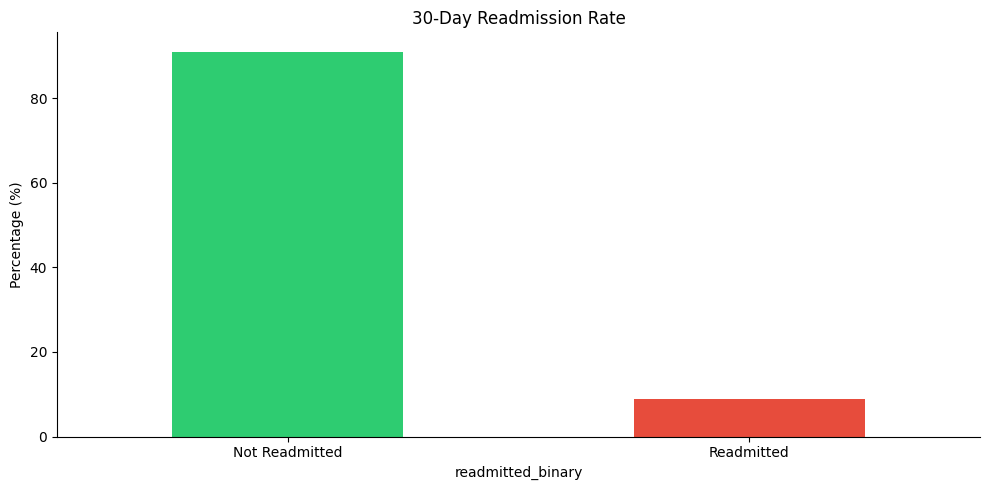

In [99]:
# Target Variable Distribution
readmit_pct = df['readmitted_binary'].value_counts(normalize=True) * 100
print(readmit_pct)

# Simple Plot
readmit_pct.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('30-Day Readmission Rate')
plt.ylabel('Percentage (%)')
plt.xticks([0, 1], ['Not Readmitted', 'Readmitted'], rotation=0)
plt.tight_layout()
plt.show()

# Patient Demographics Analysis

**Which patient groups are being readmitted the most?**

age
[0-10)       1.960784
[10-20)      4.868914
[20-30)      7.404103
[30-40)      6.983655
[40-50)      7.410662
[50-60)      7.117985
[60-70)      9.002805
[70-80)     10.236620
[80-90)     10.763826
[90-100)     9.545455
Name: readmitted_binary, dtype: float64


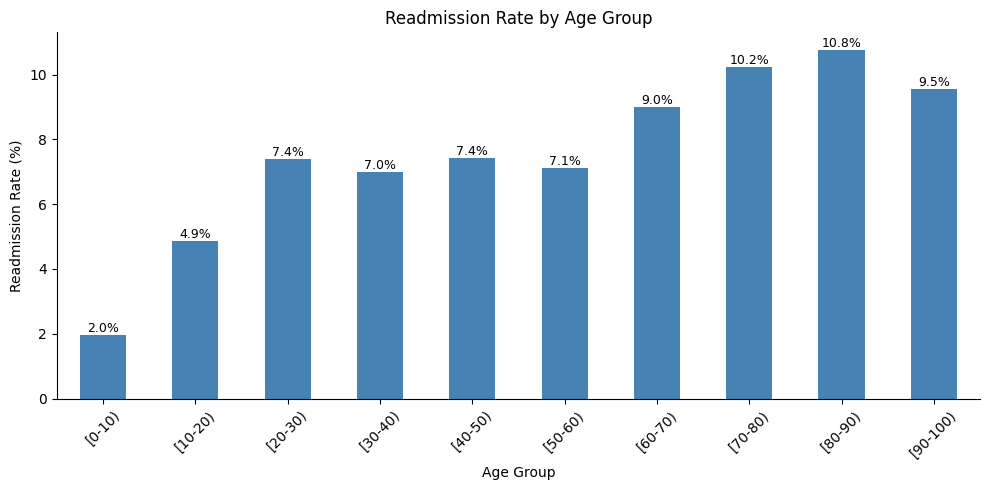

In [109]:
# Readmission Rate by Age Group
age_rate = df.groupby('age')['readmitted_binary'].mean() * 100
print(age_rate)

ax = age_rate.plot(kind='bar', color='steelblue')
# Data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)


plt.title('Readmission Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [117]:
# Remove Unknown/Invalid FIRST
df = df[df['gender'] != 'Unknown/Invalid']

gender
Female    9.027908
Male      8.906264
Name: readmitted_binary, dtype: float64


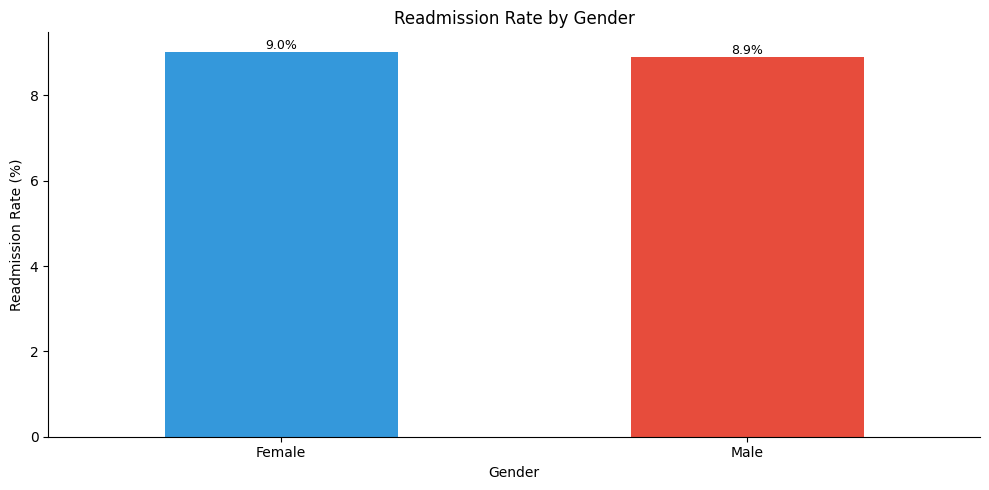

In [118]:
# Readmission Rate by Gender
gender_rate = df.groupby('gender')['readmitted_binary'].mean() * 100
print(gender_rate)

ax = gender_rate.plot(kind='bar', color=['#3498db', '#e74c3c'])
# Data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.title('Readmission Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

race
Caucasian          9.181137
AfricanAmerican    8.657426
Asian              8.401639
Hispanic           8.133333
Unknown            7.351408
Other              6.869565
Name: readmitted_binary, dtype: float64


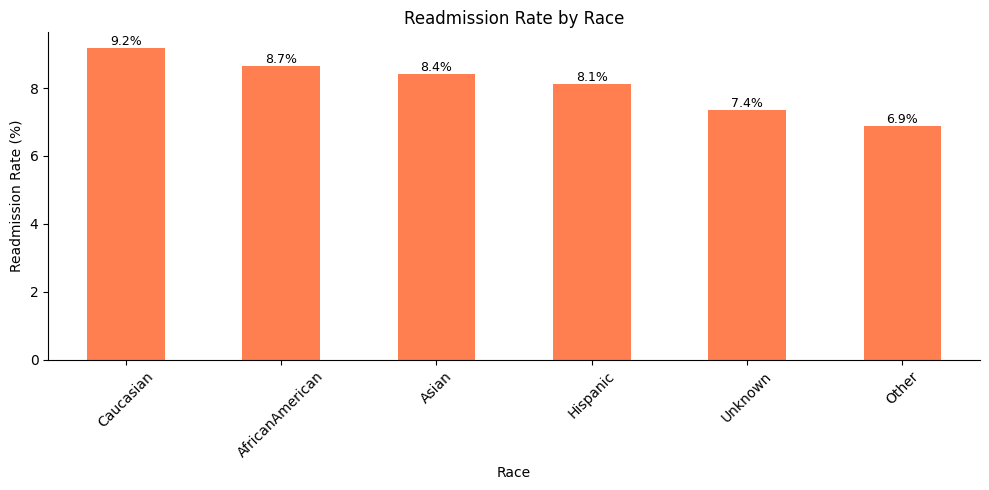

In [111]:
# Readmission Rate by Race
race_rate = df.groupby('race')['readmitted_binary'].mean() * 100
race_rate = race_rate.sort_values(ascending=False)
print(race_rate)

ax = race_rate.plot(kind='bar', color='coral')
# Data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.title('Readmission Rate by Race')
plt.xlabel('Race')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [114]:
df = df[df['gender'] != 'Unknown/Invalid']

gender       Female       Male
age                           
[0-10)     1.250000   2.739726
[10-20)    5.315615   4.291845
[20-30)    7.565337   7.106599
[30-40)    6.414368   7.766990
[40-50)    7.469376   7.354209
[50-60)    7.400000   6.851473
[60-70)    8.900797   9.101096
[70-80)   10.106104  10.390084
[80-90)   10.846210  10.633852
[90-100)   9.200000  10.392157


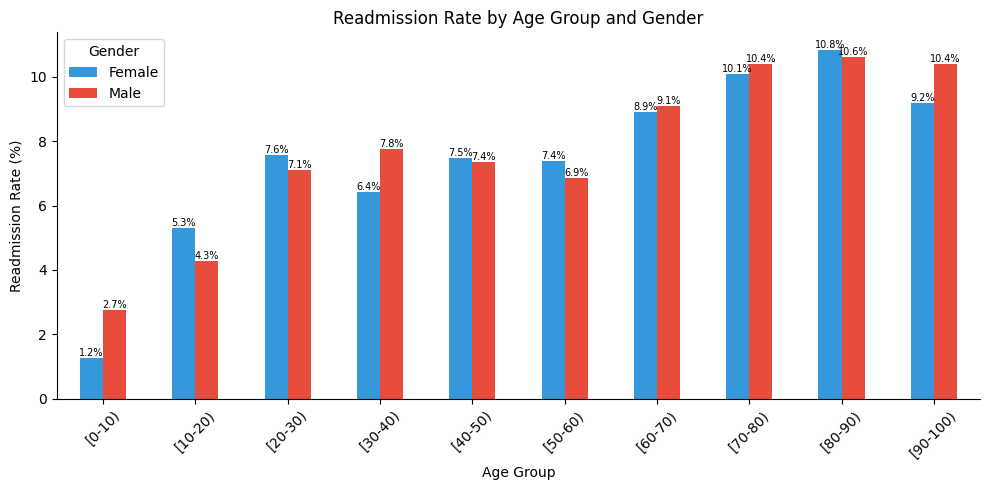

In [119]:
# Readmission Rate by Age + Gender Combined
age_gender_rate = df.groupby(['age', 'gender'])['readmitted_binary'].mean() * 100
age_gender_rate = age_gender_rate.unstack()
print(age_gender_rate)

ax = age_gender_rate.plot(kind='bar', color=['#3498db', '#e74c3c'])
# Data labels for grouped bar chart
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # only show label if bar has value
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=7)

plt.title('Readmission Rate by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


# Clinical & Hospital Stay Analysis

**Does illness severity and length of stay affect readmission?**

stay_category
Extended Stay (10+ days)    11.312849
Long Stay (6-9 days)        11.535936
Medium Stay (3-5 days)       8.777572
Short Stay (1-2 days)        7.144750
Name: readmitted_binary, dtype: float64


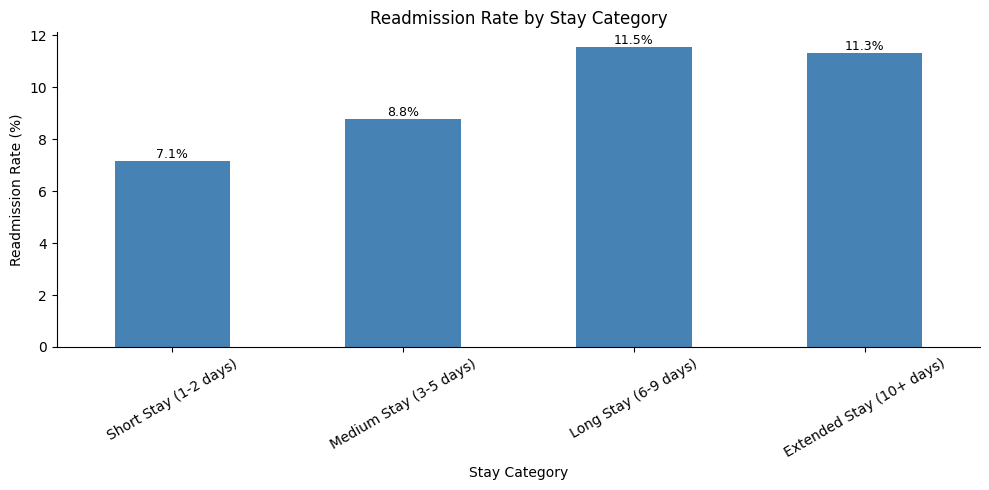

In [124]:
#Readmission Rate by Stay Category

stay_rate = df.groupby('stay_category')['readmitted_binary'].mean() * 100
print(stay_rate)

# Define correct order
order = ['Short Stay (1-2 days)', 'Medium Stay (3-5 days)', 
         'Long Stay (6-9 days)', 'Extended Stay (10+ days)']
stay_rate = stay_rate.reindex(order)

ax = stay_rate.plot(kind='bar', color='steelblue')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Readmission Rate by Stay Category')
plt.xlabel('Stay Category')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

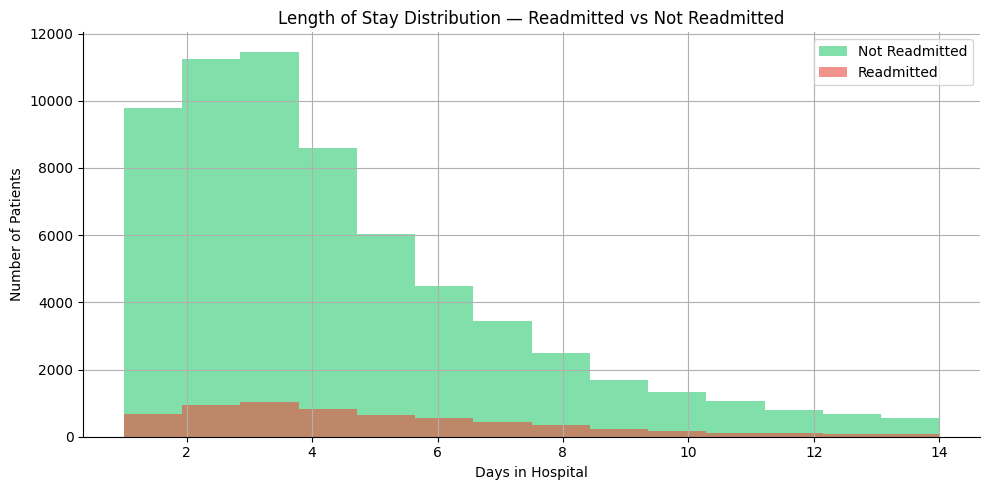

In [122]:
# Distribution of Time in Hospital (Readmitted vs Not)

df[df['readmitted_binary'] == 0]['time_in_hospital'].hist(
    alpha=0.6, bins=14, color='#2ecc71', label='Not Readmitted')
df[df['readmitted_binary'] == 1]['time_in_hospital'].hist(
    alpha=0.6, bins=14, color='#e74c3c', label='Readmitted')

plt.title('Length of Stay Distribution — Readmitted vs Not Readmitted')
plt.xlabel('Days in Hospital')
plt.ylabel('Number of Patients')
plt.legend()
plt.tight_layout()
plt.show()

number_diagnoses
1      3.108808
2      4.653802
3      5.939754
4      6.777753
5      7.702703
6      8.577848
7      8.617234
8      9.768638
9     10.031593
10    11.111111
11    16.666667
12    16.666667
13    10.000000
14    20.000000
15    14.285714
16    10.000000
Name: readmitted_binary, dtype: float64


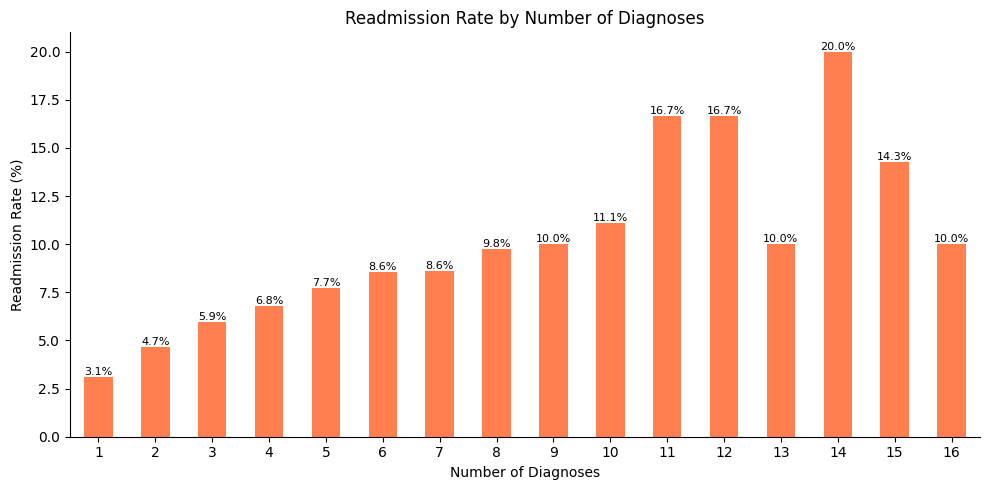

In [123]:
# Readmission Rate by Number of Diagnoses

diag_rate = df.groupby('number_diagnoses')['readmitted_binary'].mean() * 100
print(diag_rate)

ax = diag_rate.plot(kind='bar', color='coral')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=8)

plt.title('Readmission Rate by Number of Diagnoses')
plt.xlabel('Number of Diagnoses')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\Ronita Karmakar\AppData\Local\Temp\ipykernel_10460\1235042956.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  severity_rate = df.groupby('severity_bucket')['readmitted_binary'].mean() * 100


severity_bucket
Low        7.092500
Medium     9.906000
High      11.343805
Name: readmitted_binary, dtype: float64


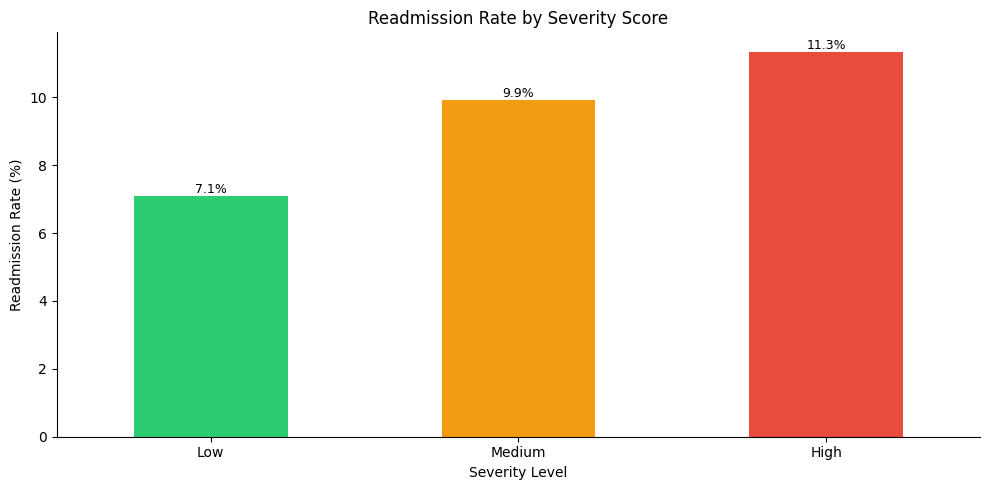

In [125]:
# Readmission Rate by Severity Score Buckets

# Create severity buckets first
df['severity_bucket'] = pd.cut(df['severity_score'],
                                bins=3,
                                labels=['Low', 'Medium', 'High'])

severity_rate = df.groupby('severity_bucket')['readmitted_binary'].mean() * 100
print(severity_rate)

ax = severity_rate.plot(kind='bar', color=['#2ecc71', '#f39c12', '#e74c3c'])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Readmission Rate by Severity Score')
plt.xlabel('Severity Level')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

high_risk
0     8.708147
1    17.407758
Name: readmitted_binary, dtype: float64


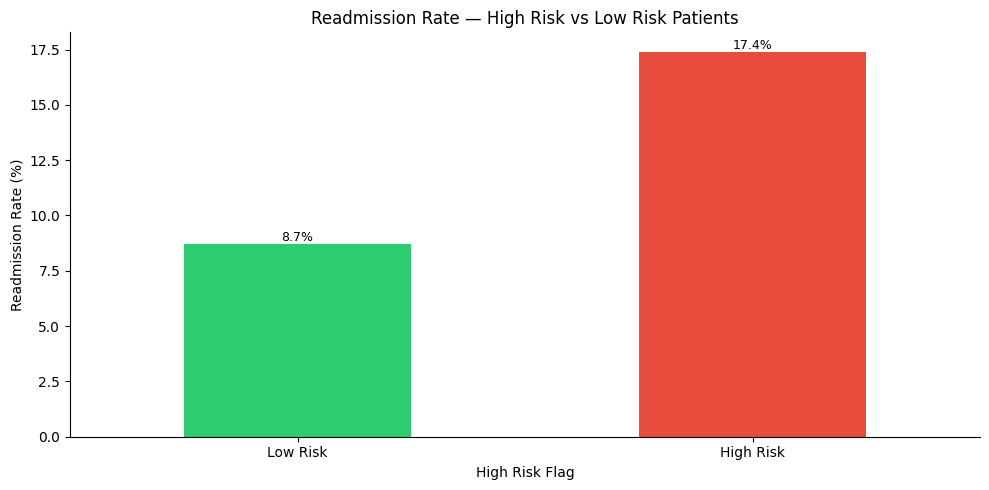

In [126]:
# Readmission Rate by High Risk Flag

risk_rate = df.groupby('high_risk')['readmitted_binary'].mean() * 100
print(risk_rate)

ax = risk_rate.plot(kind='bar', color=['#2ecc71', '#e74c3c'])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Readmission Rate — High Risk vs Low Risk Patients')
plt.xlabel('High Risk Flag')
plt.ylabel('Readmission Rate (%)')
plt.xticks([0, 1], ['Low Risk', 'High Risk'], rotation=0)
plt.tight_layout()
plt.show()

# Admission & Discharge Analysis

**Does how a patient enters and leaves the hospital affect readmission?**

In [132]:
# Remove Trauma — too few records, not relevant to diabetes analysis
df = df[df['admission_type'] != 'Trauma']

In [138]:
# Remove from admission type
df = df[~df['admission_type'].isin(['Not Available', 'Not Mapped', 'NULL'])]

admission_type
Newborn      12.500000
Emergency     9.170380
Urgent        8.968049
Elective      8.277713
Name: readmitted_binary, dtype: float64


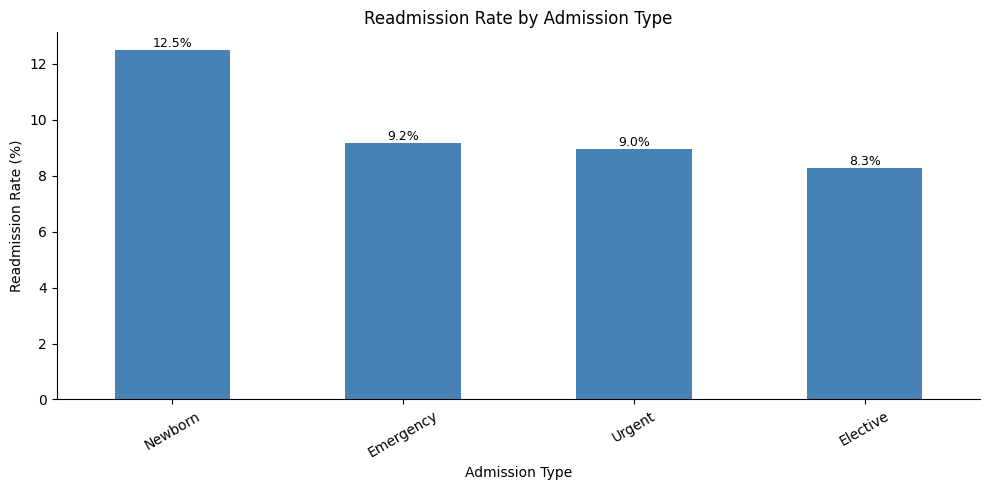

In [139]:
# Readmission Rate by Admission Type

admit_rate = df.groupby('admission_type')['readmitted_binary'].mean() * 100
admit_rate = admit_rate.sort_values(ascending=False)
print(admit_rate)

ax = admit_rate.plot(kind='bar', color='steelblue')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Readmission Rate by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [134]:
# Remove Birth Related —  not relevant to diabetes
df = df[df['admission_source_group'] != 'Birth Related']

In [140]:
# Remove from admission source
df = df[df['admission_source_group'] != 'Not Available / Unknown']

admission_source_group
Court / Law Enforcement    10.000000
Emergency Room              9.155897
Referral                    8.658882
Transfer                    8.460733
Name: readmitted_binary, dtype: float64


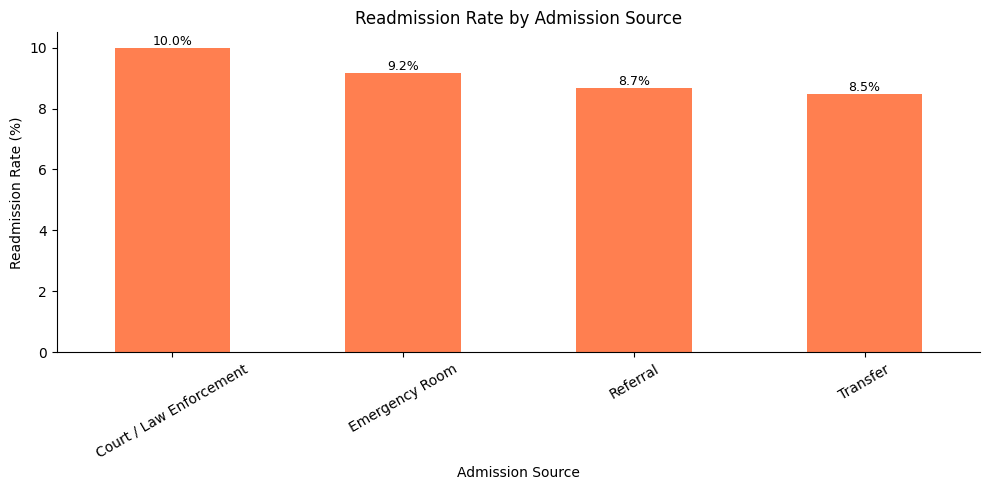

In [141]:
# Readmission Rate by Admission Source

source_rate = df.groupby('admission_source_group')['readmitted_binary'].mean() * 100
source_rate = source_rate.sort_values(ascending=False)
print(source_rate)

ax = source_rate.plot(kind='bar', color='coral')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Readmission Rate by Admission Source')
plt.xlabel('Admission Source')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [142]:
# Remove from discharge group
df = df[df['discharge_group'] != 'Not Available / Unknown']

discharge_group
Transferred to Psychiatric Care          44.262295
Continued Outpatient / Inpatient Care    25.000000
Transferred to Long Term / Rehab Care    22.702036
Transferred to Another Facility          14.031225
Left Against Medical Advice (AMA)        10.164835
Home with Health Support                  9.242983
Home                                      6.886733
Name: readmitted_binary, dtype: float64


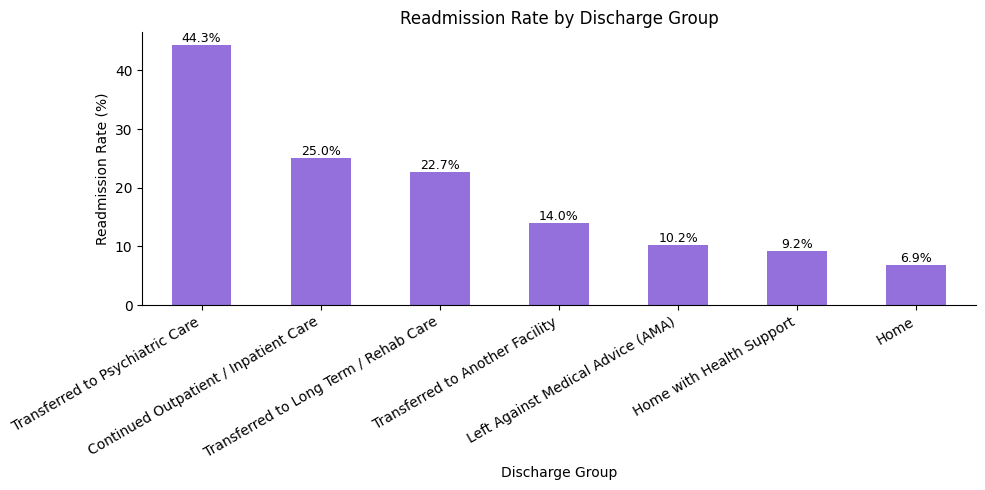

In [144]:
# Readmission Rate by Discharge Group

discharge_rate = df.groupby('discharge_group')['readmitted_binary'].mean() * 100
discharge_rate = discharge_rate.sort_values(ascending=False)
print(discharge_rate)

ax = discharge_rate.plot(kind='bar', color='mediumpurple')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Readmission Rate by Discharge Group')
plt.xlabel('Discharge Group')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Medication & Prior Utilization Analysis

**Does medication management and prior hospital usage affect readmission?**

diabetesMed
No     7.506978
Yes    9.295787
Name: readmitted_binary, dtype: float64


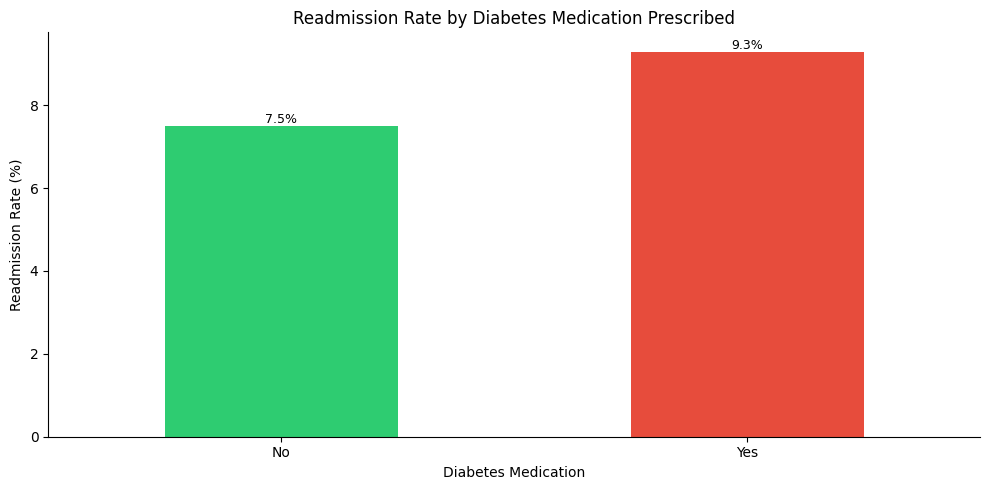

In [145]:
# Readmission Rate by Diabetes Medication Prescribed

med_rate = df.groupby('diabetesMed')['readmitted_binary'].mean() * 100
print(med_rate)

ax = med_rate.plot(kind='bar', color=['#2ecc71', '#e74c3c'])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Readmission Rate by Diabetes Medication Prescribed')
plt.xlabel('Diabetes Medication')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

change
No     8.450130
Yes    9.393128
Name: readmitted_binary, dtype: float64


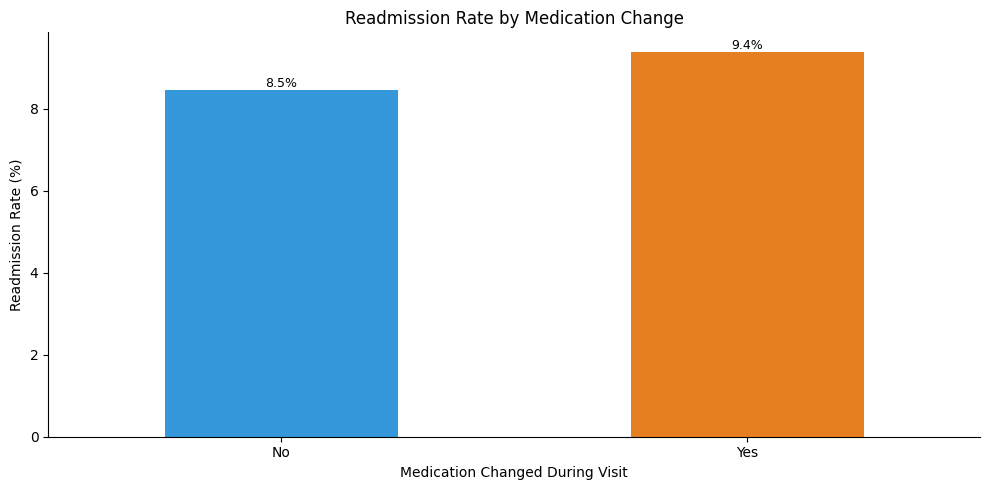

In [146]:
#  Readmission Rate by Medication Change

change_rate = df.groupby('change')['readmitted_binary'].mean() * 100
print(change_rate)

ax = change_rate.plot(kind='bar', color=['#3498db', '#e67e22'])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Readmission Rate by Medication Change')
plt.xlabel('Medication Changed During Visit')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

active_med_count
0    7.516456
1    9.564921
2    9.057632
3    8.864865
4    7.936508
5    0.000000
Name: readmitted_binary, dtype: float64


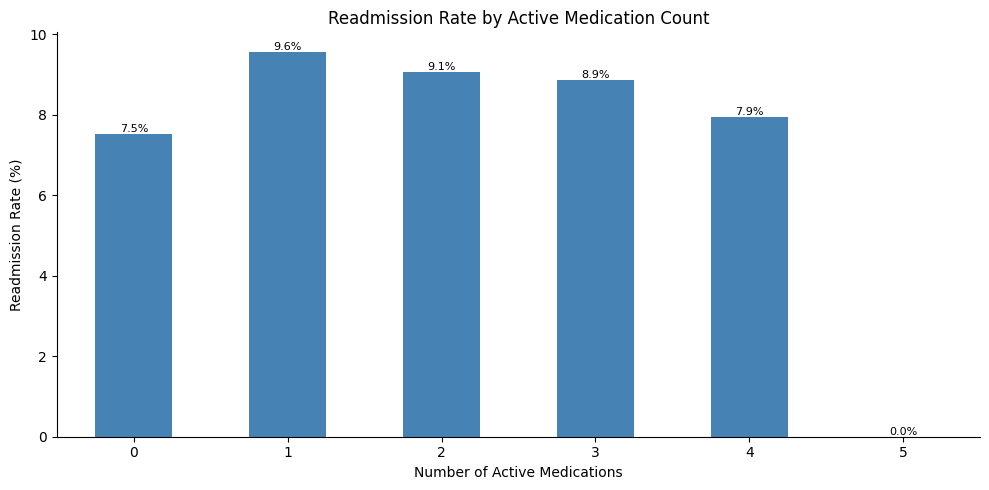

In [147]:
# Readmission Rate by Active Medication Count

active_med_rate = df.groupby('active_med_count')['readmitted_binary'].mean() * 100
print(active_med_rate)

ax = active_med_rate.plot(kind='bar', color='steelblue')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=8)

plt.title('Readmission Rate by Active Medication Count')
plt.xlabel('Number of Active Medications')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

prior_visits_group
0 Visits       7.894976
1-3 Visits    11.182591
4-7 Visits    15.453029
8+ Visits     16.076294
Name: readmitted_binary, dtype: float64


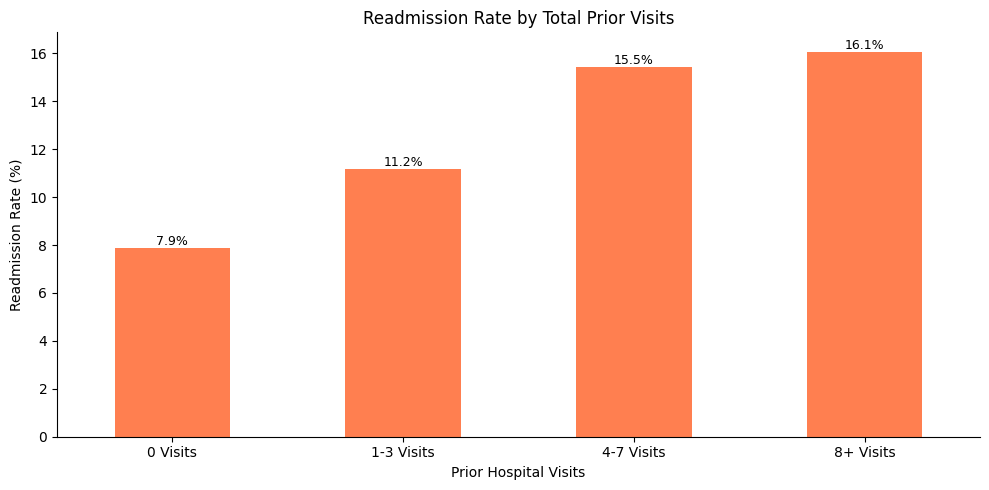

In [148]:
# Readmission Rate by Total Prior Visits

# Group total prior visits into buckets first
def group_prior_visits(val):
    if val == 0:
        return '0 Visits'
    elif val <= 3:
        return '1-3 Visits'
    elif val <= 7:
        return '4-7 Visits'
    else:
        return '8+ Visits'

df['prior_visits_group'] = df['total_prior_visits'].apply(group_prior_visits)

order = ['0 Visits', '1-3 Visits', '4-7 Visits', '8+ Visits']
prior_rate = df.groupby('prior_visits_group')['readmitted_binary'].mean() * 100
prior_rate = prior_rate.reindex(order)
print(prior_rate)

ax = prior_rate.plot(kind='bar', color='coral')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Readmission Rate by Total Prior Visits')
plt.xlabel('Prior Hospital Visits')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

inpatient_group
0      8.065168
1     12.814174
2     17.459016
3     22.666667
4     25.966851
5+    36.746988
Name: readmitted_binary, dtype: float64


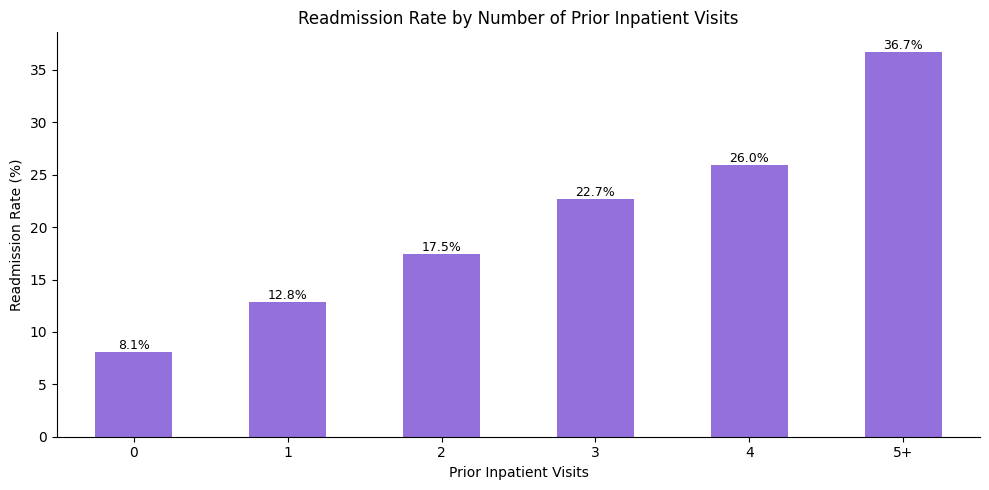

In [149]:
# Readmission Rate by Number of Inpatient Visits

# Cap at 5+ to avoid too many bars
df['inpatient_group'] = df['number_inpatient'].apply(
    lambda x: '5+' if x >= 5 else str(x)
)

order = ['0', '1', '2', '3', '4', '5+']
inpatient_rate = df.groupby('inpatient_group')['readmitted_binary'].mean() * 100
inpatient_rate = inpatient_rate.reindex(order)
print(inpatient_rate)

ax = inpatient_rate.plot(kind='bar', color='mediumpurple')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Readmission Rate by Number of Prior Inpatient Visits')
plt.xlabel('Prior Inpatient Visits')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Diagnosis Analysis

**Which diseases are driving the most readmissions?**

In [151]:
# Remove from discharge group
df = df[df['diag_1_category'] != 'Unknown']

diag_1_category
External/Supplementary    13.788301
Injury                    10.866299
Circulatory                9.588888
Diabetes                   8.890701
Neoplasms                  8.805901
Genitourinary              8.768971
Other                      8.448622
Musculoskeletal            8.408408
Digestive                  7.988220
Respiratory                7.194610
Name: readmitted_binary, dtype: float64


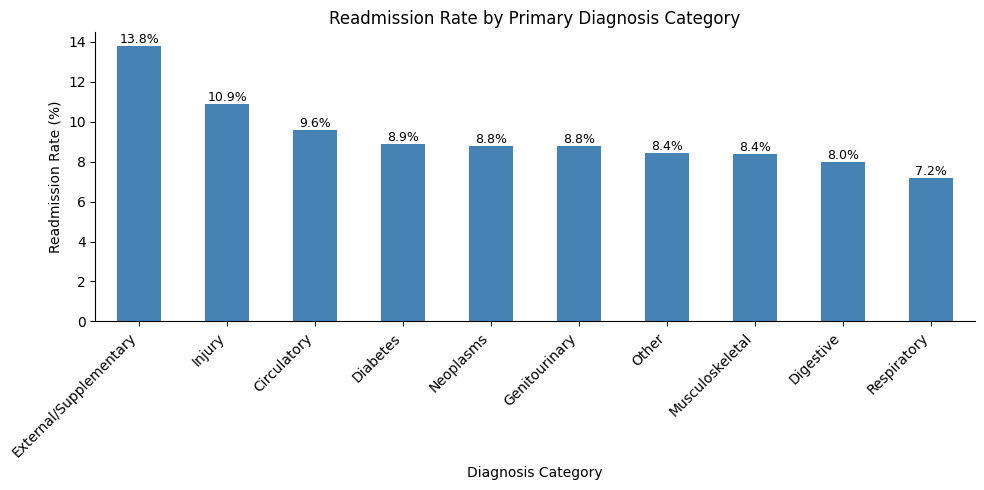

In [152]:
# Readmission rate by primary diagnosis category

diag_rate = df.groupby('diag_1_category')['readmitted_binary'].mean() * 100
diag_rate = diag_rate.sort_values(ascending=False)
print(diag_rate)

ax = diag_rate.plot(kind='bar', color='steelblue')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Readmission Rate by Primary Diagnosis Category')
plt.xlabel('Diagnosis Category')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

diag_1_category
Circulatory               1719
Other                      800
Respiratory                566
Diabetes                   436
Injury                     434
Digestive                  434
Musculoskeletal            280
Genitourinary              260
Neoplasms                  191
External/Supplementary      99
Name: count, dtype: int64


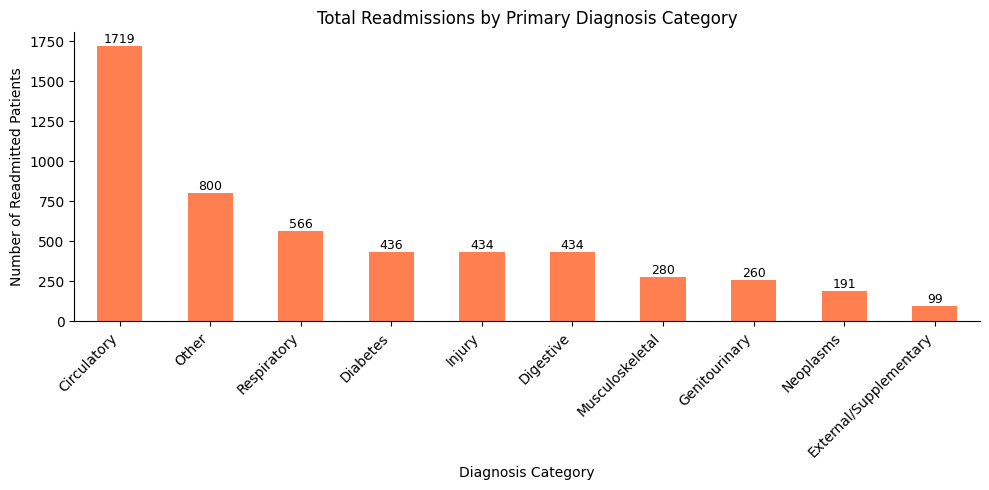

In [153]:
# Top diagnosis categories by volume of readmissions

# This shows total COUNT of readmitted patients per diagnosis
# not just the rate — tells you where the most readmissions are happening
diag_volume = df[df['readmitted_binary'] == 1]['diag_1_category'].value_counts()
print(diag_volume)

ax = diag_volume.plot(kind='bar', color='coral')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Total Readmissions by Primary Diagnosis Category')
plt.xlabel('Diagnosis Category')
plt.ylabel('Number of Readmitted Patients')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Correlation Analysis

**Which numeric variables are most strongly related to readmission?**

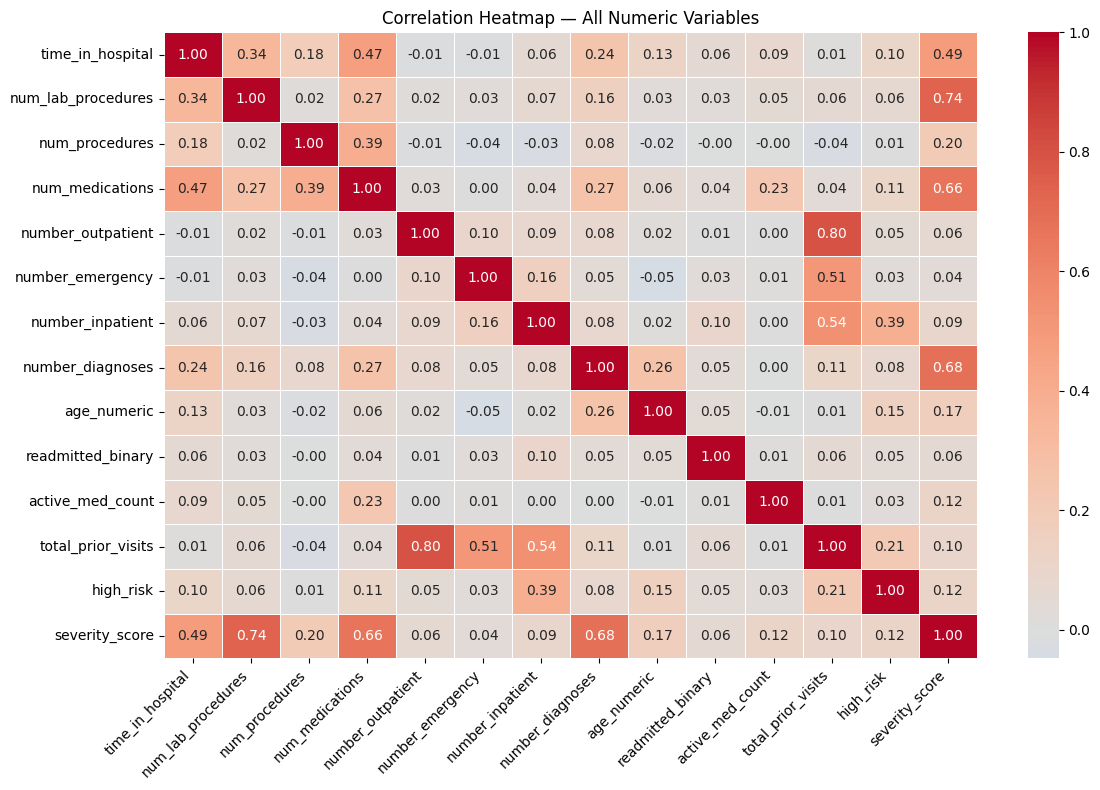

In [154]:
# Correlation heatmap of all numeric columns

# Select only numeric columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()

# Remove patient_nbr — identifier, not a feature
numeric_cols.remove('patient_nbr')

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.title('Correlation Heatmap — All Numeric Variables')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

number_inpatient      0.098612
total_prior_visits    0.057181
time_in_hospital      0.055426
severity_score        0.055281
high_risk             0.049386
Name: readmitted_binary, dtype: float64


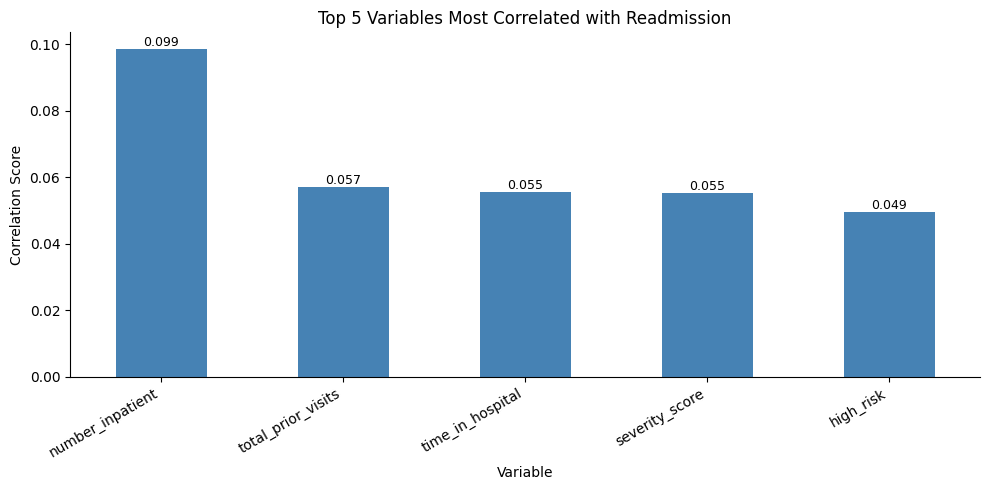

In [156]:
# Identify top 5 variables most correlated with readmitted_binary

# Step 1 — Get correlation of every numeric column with readmitted_binary
target_corr = df[numeric_cols].corr()['readmitted_binary']

# Step 2 — Remove readmitted_binary itself (it will show 1.0 — not useful)
target_corr = target_corr.drop('readmitted_binary')

# Step 3 — Sort by strongest correlation (use abs() to treat negative same as positive)
target_corr = target_corr.abs().sort_values(ascending=False)

# Step 4 — Take top 5
top5 = target_corr.head(5)

print(top5)

# Step 5 — Plot
ax = top5.plot(kind='bar', color='steelblue')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Top 5 Variables Most Correlated with Readmission')
plt.xlabel('Variable')
plt.ylabel('Correlation Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [157]:
# Save this clean file
df.to_csv('diabetic_cleaned.csv', index=False)

In [158]:
df.shape

(58776, 29)